In [2]:
import pandas as pd
from datetime import datetime
import googlemaps
from dotenv import load_dotenv 
import os
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('dark_background')

load_dotenv()

GOOGLEMAPS_API_KEY = os.getenv("GOOGLEMAPS_API_KEY")

BIXI_CSV_PATH = "./DonneesOuvertes2025_010203040506070809101112.csv"

gm = googlemaps.Client(key=GOOGLEMAPS_API_KEY)

In [3]:
df = pd.read_csv(BIXI_CSV_PATH, header=0)

In [4]:
df.head()

,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Parc Émilie-Gamelin (St-Hubert / de Maisonneuv...,Ville-Marie,45.515868,-73.560084,NaN,NaN,NaN,NaN,1741120865258,NaN
1,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,45.524247,-73.581662,NaN,NaN,NaN,NaN,1741144108111,NaN
2,Notre-Dame / St-Martin,Le Sud-Ouest,45.488302,-73.568718,NaN,NaN,NaN,NaN,1741094909506,NaN
3,de Maisonneuve / Greene,Westmount,45.486971,-73.589293,NaN,NaN,NaN,NaN,1741098869605,NaN
4,Métro Sherbrooke (de Rigaud / Berri),Le Plateau-Mont-Royal,45.518143,-73.568004,NaN,NaN,NaN,NaN,1741094527644,NaN


In [5]:
start_time, end_time = df[["STARTTIMEMS", "ENDTIMEMS"]].dropna().to_numpy().T

In [6]:
duration = (end_time - start_time)/(60 * 1000)

In [7]:
duration

array([18.0368    , 18.11136667, 18.76981667, ..., 43.01811667,
       40.74928333,  6.76313333], shape=(14197541,))

In [8]:
np.mean(duration)

np.float64(16.82098306114418)

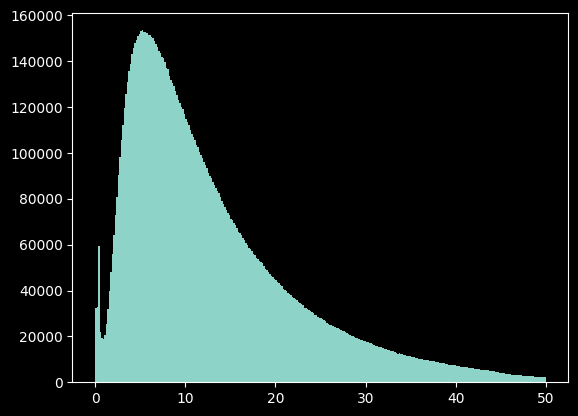

In [9]:
plt.hist(duration, bins=300, range=(0, 50))
plt.show()

In [46]:
pd.DataFrame(duration/60).describe()

,0
count,1.419754e+07
mean,2.803497e-01
std,6.141858e+00
min,1.472222e-05
25%,1.011256e-01
50%,1.753111e-01
75%,2.992083e-01
max,6.187157e+03


In [10]:
# Geocoding an address
geocode_result = gm.geocode('1600 Amphitheatre Parkway, Mountain View, CA')

# Look up an address with reverse geocoding
reverse_geocode_result = gm.reverse_geocode((40.714224, -73.961452))

# Request directions via public transit
now = datetime.now()
directions_result = gm.directions("Sydney Town Hall",
                                     "Parramatta, NSW",
                                     mode="transit",
                                     departure_time=now)

# Validate an address with address validation
addressvalidation_result =  gm.addressvalidation(['1600 Amphitheatre Pk'], 
                                                    regionCode='US',
                                                    locality='Mountain View', 
                                                    enableUspsCass=True)

# Get an Address Descriptor of a location in the reverse geocoding response
address_descriptor_result = gm.reverse_geocode((40.714224, -73.961452))

print(geocode_result)


[{'address_components': [{'long_name': 'Google Building 41', 'short_name': 'Google Building 41', 'types': ['premise']}, {'long_name': '1600', 'short_name': '1600', 'types': ['street_number']}, {'long_name': 'Amphitheatre Parkway', 'short_name': 'Amphitheatre Pkwy', 'types': ['route']}, {'long_name': 'Mountain View', 'short_name': 'Mountain View', 'types': ['locality', 'political']}, {'long_name': 'Santa Clara County', 'short_name': 'Santa Clara County', 'types': ['administrative_area_level_2', 'political']}, {'long_name': 'California', 'short_name': 'CA', 'types': ['administrative_area_level_1', 'political']}, {'long_name': 'United States', 'short_name': 'US', 'types': ['country', 'political']}, {'long_name': '94043', 'short_name': '94043', 'types': ['postal_code']}, {'long_name': '1351', 'short_name': '1351', 'types': ['postal_code_suffix']}], 'formatted_address': 'Google Building 41, 1600 Amphitheatre Pkwy, Mountain View, CA 94043, USA', 'geometry': {'bounds': {'northeast': {'lat': 3

In [11]:
directions_result

[{'bounds': {'northeast': {'lat': -33.8148584, 'lng': 151.208821},
   'southwest': {'lat': -33.89778769999999, 'lng': 151.0017776}},
  'copyrights': 'Powered by Google, ©2026 Google',
  'legs': [{'arrival_time': {'text': '6:48\u202fAM',
     'time_zone': 'Australia/Sydney',
     'value': 1779914882},
    'departure_time': {'text': '6:08\u202fAM',
     'time_zone': 'Australia/Sydney',
     'value': 1779912525},
    'distance': {'text': '25.1 km', 'value': 25098},
    'duration': {'text': '39 mins', 'value': 2357},
    'end_address': 'Parramatta NSW 2150, Australia',
    'end_location': {'lat': -33.8148584, 'lng': 151.0017776},
    'start_address': '483 George St, Sydney NSW 2000, Australia',
    'start_location': {'lat': -33.8732056, 'lng': 151.2069231},
    'steps': [{'distance': {'text': '56 m', 'value': 56},
      'duration': {'text': '1 min', 'value': 48},
      'end_location': {'lat': -33.8735668, 'lng': 151.2069088},
      'html_instructions': 'Walk to Town Hall',
      'polyline'

In [13]:
import json

In [17]:
with open("directions_result.json", "w") as f:
    json.dump(directions_result, f, indent=4)